# ============================================================
# TRADECLEANSE — NOTEBOOK 01 : Audit & Profiling Initial
# DCLE821 — QuantAxis Capital
# Etudiant(s) : Kaouther TRABELSI
# Date        : 15/04/2026
# ============================================================

## ============================================================
## CELLULE 1 — Chargement multi-sources
## ============================================================
 CONSIGNE :
 Le dataset consolide 3 sources heterogenes :
   - Bloomberg   : fichier CSV (colonnes marche : bid, ask, mid_price, price,
                                volume_j, volatility_30d)
   - Murex (SQL) : transactions internes (trade_id, dates, notional, quantity,
                                          trader_id, asset_class)
   - Refinitiv   : donnees fondamentales (credit_rating, sector,
                                          counterparty_name, country_risk)

 TACHE :
   1. Chargez tradecleanse_raw.csv avec les parametres d'import appropries.
      Pensez a gerer : encodage, separateur, valeurs sentinelles connues,
      types de colonnes.
   2. Simulez les 3 sources en creant 3 sous-dataframes avec uniquement
      les colonnes correspondant a chaque source.
   3. Ajoutez une colonne "source" sur chacun avant consolidation.

 LIBRAIRIES SUGGÉREES : pandas, sqlite3 (pour simuler Murex en SQL)

In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Mon code ici ---

# ── 1. Paramètres d'import ────────────────────────────────────────────────────
# Valeurs sentinelles observées dans les exports Bloomberg / Murex / Refinitiv
NA_VALUES = ["N/A", "NA", "#N/A", "#N/A N/A", "-", "NULL", "", " ", "n/a", "none", "#VALUE!", "nd"]

DTYPES = {
    # ── Murex (transactions internes) ──────────────────────────────────────
    "trade_id"       : "string",
    "counterparty_id": "string",
    "asset_class"    : "category",   # equity/bond/derivative/fx
    "notional_eur"   : "float64",
    "quantity"       : "Int64",       # Int64 nullable (gère les NaN entiers)
    "trader_id"      : "string",
    # ── Bloomberg (données de marché) ──────────────────────────────────────
    "isin"           : "string",
    "price"          : "float64",
    "bid"            : "float64",
    "ask"            : "float64",
    "mid_price"      : "float64",
    "volume_j"       : "Int64",       # volume journalier entier nullable
    "volatility_30d" : "float64",
    # ── Refinitiv (données fondamentales) ──────────────────────────────────
    "counterparty_name": "string",
    "credit_rating"    : "category",  # AAA/AA/A/BBB/BB/B/CCC/D
    "default_flag"     : "Int64",      # 0/1 nullable (pas de float)
    "sector"           : "string",
    "country_risk"     : "float64",   # score 0-100
}

PARSE_DATES = ["trade_date", "settlement_date"]

# ── 2. Chargement du fichier consolidé ────────────────────────────────────────
df_raw = pd.read_csv(
    "data/tradecleanse_raw.csv",
    sep             = ",",         # séparateur standard exports FR/Murex
    encoding        = "latin1", # gère le BOM éventuel des exports Windows
    na_values       = NA_VALUES,
    keep_default_na = True,
    dtype           = DTYPES,
    parse_dates     = PARSE_DATES,
    dayfirst        = True,        # format JJ/MM/AAAA courant en Europe
    decimal         = ",",          # décimale virgule dans les exports FR
    thousands       = ".",         # séparateur milliers
    low_memory      = False,       # évite les DtypeWarning sur colonnes mixtes
)

df_raw.info()

# Statistiques descriptives
df_raw.describe(include="all")

print(f"✓ Chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes\n")
print(df_raw.dtypes.to_string())

# ── 3. Simulation des 3 sous-dataframes par source ───────────────────────────

COLS_MUREX = [
    "trade_id", "counterparty_id", "trade_date", "settlement_date",
    "asset_class", "notional_eur", "quantity", "trader_id",
]
COLS_BLOOMBERG = [
    "isin", "price", "bid", "ask", "mid_price", "volume_j", "volatility_30d",
]
COLS_REFINITIV = [
    "counterparty_name", "credit_rating", "default_flag", "sector", "country_risk",
]

# Sélection défensive : uniquement les colonnes effectivement présentes
def safe_select(df: pd.DataFrame, cols: list, source: str) -> pd.DataFrame:
    present = [col for col in cols if col in df.columns]
    missing = set(cols) - set(present)
    if missing:
        print(f"   [{source}] colonnes absentes du fichier : {sorted(missing)}")
    sub = df[present].copy()
    sub["source"] = source   # ← colonne de traçabilité
    return sub

df_murex     = safe_select(df_raw, COLS_MUREX,     "Murex")
df_bloomberg = safe_select(df_raw, COLS_BLOOMBERG, "Bloomberg")
df_refinitiv = safe_select(df_raw, COLS_REFINITIV, "Refinitiv")

df_murex.head()
df_bloomberg.head()
df_refinitiv.head()

for name, sub in [("Murex", df_murex), ("Bloomberg", df_bloomberg), ("Refinitiv", df_refinitiv)]:
    print(f"\n── {name} ({sub.shape[1]-1} cols + 'source') ──────────────────")
    print(sub.head(2).to_string(index=False))

# ── 4. Consolidation (union horizontale — même index ligne) ───────────────────
#  Les 3 sources décrivent le même trade : on les réassemble côte à côte.
#  On retire la colonne "source" redondante avant concat, puis on la pose
#  sur df_consolidated avec la valeur "consolidated".
df_consolidated = pd.concat(
    [
        df_murex.drop(columns="source"),
        df_bloomberg.drop(columns="source"),
        df_refinitiv.drop(columns="source"),
    ],
    axis=1,
)
df_consolidated["source"] = "consolidated"

print(f"\n✓ df_consolidated : {df_consolidated.shape[0]:,} lignes × {df_consolidated.shape[1]} colonnes")
print(f"  Colonnes : {list(df_consolidated.columns)}")
print(f"\n  NaN par colonne :\n{df_consolidated.isna().sum().to_string()}")


<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   trade_id           8950 non-null   string        
 1   counterparty_id    8950 non-null   string        
 2   counterparty_name  8950 non-null   string        
 3   isin               8950 non-null   string        
 4   trade_date         8950 non-null   str           
 5   settlement_date    8950 non-null   datetime64[us]
 6   asset_class        8950 non-null   category      
 7   notional_eur       8950 non-null   float64       
 8   price              8950 non-null   float64       
 9   quantity           8950 non-null   Int64         
 10  bid                8950 non-null   float64       
 11  ask                8950 non-null   float64       
 12  mid_price          8950 non-null   float64       
 13  volume_j           8950 non-null   Int64         
 14  volatility_30d     

## ============================================================
## CELLULE 2 — Profiling initial
## ============================================================
 CONSIGNE :
 Produisez un rapport de profiling complet du dataset brut.
 Il doit contenir au minimum :
   - Shape (nb lignes, nb colonnes)
   - Types detectes par pandas
   - Taux de valeurs manquantes par colonne (count + %)
   - Statistiques descriptives (min, max, mean, std, quartiles)
     pour toutes les colonnes numeriques
   - Cardinalite (nb de valeurs uniques) pour les colonnes categorielles
   - Distribution de chaque colonne categorielle (value_counts)
   - Nombre de doublons exacts et doublons sur trade_id

 LIBRAIRIES SUGGÉREES : pandas (.describe, .isnull, .value_counts, .duplicated)

In [21]:
# shape & types
print("═" * 60)
print(f"SHAPE     : {df_consolidated.shape[0]:,} lignes × {df_consolidated.shape[1]} colonnes")
print("─" * 60)
print("TYPES PANDAS :")
print(df_consolidated.dtypes.to_string())
# valeurs manquantes
print("\n" + "═" * 60)
print("VALEURS MANQUANTES")
print("─" * 60)

n = len(df_consolidated)
missing = (
    pd.DataFrame({
        "dtype"  : df_consolidated.dtypes,
        "count"  : df_consolidated.isna().sum(),
        "pct"    : df_consolidated.isna().mean().mul(100).round(2),
    })
    .sort_values("pct", ascending=False)
)
missing["flag"] = missing["pct"].apply(
    lambda x: "🔴" if x > 20 else ("🟡" if x > 5 else "🟢")
)
print(missing.to_string())
print(f"\n  Total cellules manquantes : {df_consolidated.isna().sum().sum():,} / {n * df_consolidated.shape[1]:,}")
# statistiques descriptives — colonnes numériques
print("\n" + "═" * 60)
print("STATISTIQUES DESCRIPTIVES (colonnes numériques)")
print("─" * 60)

num_cols = df_consolidated.select_dtypes(include=["number"]).columns.tolist()

desc = (
    df_consolidated[num_cols]
    .describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
    .T                          # colonnes en lignes → plus lisible
    .assign(
        skew = df_consolidated[num_cols].skew().round(3),
        kurt = df_consolidated[num_cols].kurt().round(3),
    )
)
print(desc.to_string())
# cardinalité & distributions — colonnes catégorielles
print("\n" + "═" * 60)
print("COLONNES CATÉGORIELLES")

cat_cols = df_consolidated.select_dtypes(include=["category", "object", "string"]).columns.tolist()

for col in cat_cols:
    vc        = df_consolidated[col].value_counts(dropna=False)
    n_unique  = df_consolidated[col].nunique(dropna=True)
    n_missing = df_consolidated[col].isna().sum()
    pct_miss  = n_missing / n * 100

    print(f"\n── {col}")
    print(f"   Cardinalité : {n_unique} valeurs uniques  |  Manquants : {n_missing} ({pct_miss:.1f}%)")

    # Pour les colonnes haute-cardinalité (IDs, noms), on n'affiche que le top-10
    MAX_DISPLAY = 15 if n_unique <= 15 else 10
    vc_pct = (vc / n * 100).round(2)
    summary = pd.DataFrame({"count": vc, "pct": vc_pct}).head(MAX_DISPLAY)
    print(summary.to_string())
    if n_unique > MAX_DISPLAY:
        print(f"   … ({n_unique - MAX_DISPLAY} autres valeurs non affichées)")
# doublons
print("\n" + "═" * 60)
print("DOUBLONS")
print("─" * 60)

# Doublons exacts (toutes colonnes sauf "source")
dup_exact = df_consolidated.drop(columns="source").duplicated().sum()
print(f"Doublons exacts (toutes colonnes)  : {dup_exact:,}  ({dup_exact/n*100:.2f}%)")

# Doublons sur trade_id uniquement
if "trade_id" in df_consolidated.columns:
    dup_tid = df_consolidated["trade_id"].duplicated(keep=False).sum()
    n_uid   = df_consolidated["trade_id"].nunique()
    print(f"Doublons sur trade_id              : {dup_tid:,}  ({dup_tid/n*100:.2f}%)")
    print(f"trade_id uniques                   : {n_uid:,} / {n:,}")

    # Affichage des trade_id qui apparaissent plus d'une fois
    dup_detail = (
        df_consolidated[df_consolidated["trade_id"].duplicated(keep=False)]
        [["trade_id", "trade_date", "notional_eur", "trader_id"]]
        .sort_values("trade_id")
    )
    if not dup_detail.empty:
        print(f"\n  Exemple de trade_id dupliqués :\n{dup_detail.head(10).to_string(index=False)}")
    else:        print("  ✓ Aucun trade_id dupliqué.")

════════════════════════════════════════════════════════════
SHAPE     : 8,950 lignes × 21 colonnes
────────────────────────────────────────────────────────────
TYPES PANDAS :
trade_id                     string
counterparty_id              string
trade_date                      str
settlement_date      datetime64[us]
asset_class                category
notional_eur                float64
quantity                      Int64
trader_id                    string
isin                         string
price                       float64
bid                         float64
ask                         float64
mid_price                   float64
volume_j                      Int64
volatility_30d              float64
counterparty_name            string
credit_rating              category
default_flag                  Int64
sector                       string
country_risk                float64
source                          str

════════════════════════════════════════════════════════════
VALEUR

 ## ============================================================
 ## CELLULE 3 — Detection des anomalies
 ## ============================================================
 CONSIGNE :
 A partir du profiling, identifiez et quantifiez chaque anomalie.
 Pour chaque anomalie trouvee, vous devez indiquer :
   - Le type (doublon / valeur manquante / outlier / incoherence / format...)
   - La ou les colonnes concernees
   - Le nombre de lignes impactees
   - La criticite metier (impact sur le modele de risque)

 Construisez un dictionnaire ou DataFrame "anomalies_report" qui recense
 tout ce que vous avez trouve.

 RAPPEL DES COLONNES ET LEURS REGLES METIER :
 -  trade_id          : doit etre unique
 -  settlement_date   : doit etre >= trade_date (regle T+2 actions)
 -  bid / ask         : bid doit toujours etre < ask
 -  mid_price         : doit etre egal a (bid + ask) / 2
 -  price             : doit se trouver dans la fourchette [bid, ask] +/- 0.5%
 -  notional_eur      : doit etre positif (sauf position short documentee)
 -  asset_class       : doit appartenir a {equity, bond, derivative, fx}
 -  credit_rating     : valeurs valides AAA AA A BBB BB B CCC D
 -  country_risk      : doit etre compris entre 0 et 100
 -  volatility_30d    : doit etre > 0 et < 200
 -  default_flag      : valeurs valides 0 ou 1 uniquement
 -  credit_rating + default_flag : un emetteur note AAA/AA/A ne peut pas avoir default_flag = 1 (contradiction)


In [22]:

# Registre central des anomalies — chaque entrée = une règle métier testée
anomalies: list[dict] = []

def register(
    type_       : str,
    colonnes    : str,
    masque      : pd.Series,
    criticite   : str,
    description : str,
    label       : str,
) -> pd.Series:
    """Enregistre une anomalie et retourne le masque pour usage ultérieur."""
    n = masque.sum()
    anomalies.append({
        "label"      : label,
        "type"       : type_,
        "colonnes"   : colonnes,
        "n_lignes"   : int(n),
        "pct"        : round(n / len(df_consolidated) * 100, 2),
        "criticite"  : criticite,
        "description": description,
    })
    return masque
# doublons
# ── Doublons exacts ───────────────────────────────────────────────────────────
mask_dup_exact = df_consolidated.drop(columns="source").duplicated(keep=False)
register(
    type_="doublon", colonnes="toutes", masque=mask_dup_exact,
    criticite="HAUTE",
    description="Lignes entièrement identiques — sur-pondération du risque",
    label="dup_exact",
)

# ── Doublons sur trade_id (même ID, contenu différent) ───────────────────────
mask_dup_tid = df_consolidated["trade_id"].duplicated(keep=False)
register(
    type_="doublon", colonnes="trade_id", masque=mask_dup_tid,
    criticite="CRITIQUE",
    description="trade_id non-unique — clé primaire violée, agrégations faussées",
    label="dup_trade_id",
)
# valeurs manquantes sur colonnes critiques
# Colonnes dont l'absence bloque le calcul de risque
CRITICAL_COLS = {
    "trade_id"    : ("CRITIQUE", "Identifiant manquant — ligne non traçable"),
    "notional_eur": ("CRITIQUE", "Exposition financière inconnue"),
    "price"       : ("CRITIQUE", "Prix d'exécution manquant — valorisation impossible"),
    "trade_date"  : ("HAUTE",    "Date d'exécution manquante — séquençage impossible"),
    "asset_class" : ("HAUTE",    "Classe d'actif inconnue — règle prudentielle inapplicable"),
    "credit_rating": ("HAUTE",   "Note de crédit absente — scoring de contrepartie impossible"),
    "counterparty_id": ("HAUTE", "Contrepartie non identifiée — exposition agrégée faussée"),
}

for col, (crit, desc) in CRITICAL_COLS.items():
    if col in df_consolidated.columns:
        register(
            type_="valeur_manquante", colonnes=col,
            masque=df_consolidated[col].isna(),
            criticite=crit, description=desc,
            label=f"missing_{col}",
        )
# incohérences de format
# ── ISIN : exactement 12 caractères alphanumériques ──────────────────────────
if "isin" in df_consolidated.columns:
    mask_isin = (
        df_consolidated["isin"].notna() &
        ~df_consolidated["isin"].str.match(r"^[A-Z]{2}[A-Z0-9]{10}$", na=False)
    )
    register(
        type_="format", colonnes="isin", masque=mask_isin,
        criticite="HAUTE",
        description="ISIN non conforme ISO 6166 (2 lettres + 10 alphanum)",
        label="fmt_isin",
    )

# ── asset_class : valeurs autorisées ─────────────────────────────────────────
VALID_ASSET = {"equity", "bond", "derivative", "fx"}
if "asset_class" in df_consolidated.columns:
    mask_ac = (
        df_consolidated["asset_class"].notna() &
        ~df_consolidated["asset_class"].str.lower().isin(VALID_ASSET)
    )
    register(
        type_="format", colonnes="asset_class", masque=mask_ac,
        criticite="HAUTE",
        description=f"Valeur hors référentiel {VALID_ASSET}",
        label="fmt_asset_class",
    )

# ── credit_rating : valeurs autorisées ───────────────────────────────────────
VALID_RATING = {"AAA", "AA", "A", "BBB", "BB", "B", "CCC", "D"}
if "credit_rating" in df_consolidated.columns:
    mask_cr = (
        df_consolidated["credit_rating"].notna() &
        ~df_consolidated["credit_rating"].astype("string").str.upper().isin(VALID_RATING)
    )
    register(
        type_="format", colonnes="credit_rating", masque=mask_cr,
        criticite="HAUTE",
        description=f"Note hors référentiel {VALID_RATING}",
        label="fmt_credit_rating",
    )

# ── default_flag : 0 ou 1 uniquement ─────────────────────────────────────────
if "default_flag" in df_consolidated.columns:
    mask_df = (
        df_consolidated["default_flag"].notna() &
        ~df_consolidated["default_flag"].isin([0, 1])
    )
    register(
        type_="format", colonnes="default_flag", masque=mask_df,
        criticite="HAUTE",
        description="Valeur hors {0, 1} — flag binaire corrompu",
        label="fmt_default_flag",
    )
# incohérences métier inter-colonnes
# ── settlement_date < trade_date (T+2 minimum pour les actions) ──────────────
if {"trade_date", "settlement_date"} <= set(df_consolidated.columns):
    both_known = df_consolidated["trade_date"].notna() & df_consolidated["settlement_date"].notna()
    mask_settle = both_known & (df_consolidated["settlement_date"] < df_consolidated["trade_date"])
    register(
        type_="incoherence", colonnes="settlement_date / trade_date", masque=mask_settle,
        criticite="CRITIQUE",
        description="settlement_date antérieure à trade_date — violation règle T+2",
        label="inco_settlement",
    )

# ── bid >= ask (fourchette inversée) ─────────────────────────────────────────
if {"bid", "ask"} <= set(df_consolidated.columns):
    both_known = df_consolidated["bid"].notna() & df_consolidated["ask"].notna()
    mask_spread = both_known & (df_consolidated["bid"] >= df_consolidated["ask"])
    register(
        type_="incoherence", colonnes="bid / ask", masque=mask_spread,
        criticite="CRITIQUE",
        description="bid ≥ ask — fourchette inversée ou nulle, spread incalculable",
        label="inco_bid_ask",
    )

# ── mid_price ≠ (bid + ask) / 2  (tolérance 0.01 %) ─────────────────────────
if {"bid", "ask", "mid_price"} <= set(df_consolidated.columns):
    all_known = df_consolidated[["bid", "ask", "mid_price"]].notna().all(axis=1)
    theoretical_mid = (df_consolidated["bid"] + df_consolidated["ask"]) / 2
    rel_diff = (df_consolidated["mid_price"] - theoretical_mid).abs() / theoretical_mid
    mask_mid = all_known & (rel_diff > 0.0001)
    register(
        type_="incoherence", colonnes="mid_price / bid / ask", masque=mask_mid,
        criticite="HAUTE",
        description="mid_price ≠ (bid+ask)/2 à 0.01% près — donnée Bloomberg incohérente",
        label="inco_mid_price",
    )

# ── price hors fourchette [bid, ask] ± 0.5 % ─────────────────────────────────
if {"bid", "ask", "price"} <= set(df_consolidated.columns):
    all_known = df_consolidated[["bid", "ask", "price"]].notna().all(axis=1)
    tol = 0.005
    lower = df_consolidated["bid"]  * (1 - tol)
    upper = df_consolidated["ask"]  * (1 + tol)
    mask_price = all_known & (
        (df_consolidated["price"] < lower) | (df_consolidated["price"] > upper)
    )
    register(
        type_="incoherence", colonnes="price / bid / ask", masque=mask_price,
        criticite="HAUTE",
        description="price hors fourchette [bid*(1-0.5%), ask*(1+0.5%)] — exécution suspecte",
        label="inco_price_spread",
    )

# ── notional_eur ≤ 0 (hors short documenté) ──────────────────────────────────
if "notional_eur" in df_consolidated.columns:
    mask_notional = df_consolidated["notional_eur"].notna() & (df_consolidated["notional_eur"] <= 0)
    register(
        type_="incoherence", colonnes="notional_eur", masque=mask_notional,
        criticite="CRITIQUE",
        description="notional ≤ 0 sans flag short — exposition négative non documentée",
        label="inco_notional",
    )

# ── country_risk hors [0, 100] ────────────────────────────────────────────────
if "country_risk" in df_consolidated.columns:
    mask_cr_range = (
        df_consolidated["country_risk"].notna() &
        ((df_consolidated["country_risk"] < 0) | (df_consolidated["country_risk"] > 100))
    )
    register(
        type_="incoherence", colonnes="country_risk", masque=mask_cr_range,
        criticite="MOYENNE",
        description="Score pays hors [0, 100] — échelle Refinitiv violée",
        label="inco_country_risk",
    )

# ── volatility_30d hors (0, 200] ─────────────────────────────────────────────
if "volatility_30d" in df_consolidated.columns:
    mask_vol = (
        df_consolidated["volatility_30d"].notna() &
        ((df_consolidated["volatility_30d"] <= 0) | (df_consolidated["volatility_30d"] > 200))
    )
    register(
        type_="incoherence", colonnes="volatility_30d", masque=mask_vol,
        criticite="HAUTE",
        description="Volatilité hors (0 %, 200 %] — donnée Bloomberg aberrante",
        label="inco_volatility",
    )

# ── credit_rating investment-grade + default_flag = 1 ────────────────────────
if {"credit_rating", "default_flag"} <= set(df_consolidated.columns):
    IG_RATINGS = {"AAA", "AA", "A"}
    both_known = df_consolidated["credit_rating"].notna() & df_consolidated["default_flag"].notna()
    mask_ig_default = (
        both_known &
        df_consolidated["credit_rating"].astype("string").str.upper().isin(IG_RATINGS) &
        (df_consolidated["default_flag"] == 1)
    )
    register(
        type_="incoherence", colonnes="credit_rating / default_flag", masque=mask_ig_default,
        criticite="CRITIQUE",
        description="Émetteur noté AAA/AA/A avec default_flag=1 — contradiction rating/défaut",
        label="inco_ig_default",
    )
# outliers statistiques (méthode IQR)
# Méthode IQR (Tukey) : outlier si valeur < Q1 - 3*IQR ou > Q3 + 3*IQR
# Seuil élargi à 3× (vs 1.5× standard) pour limiter les faux positifs
# sur des distributions financières naturellement asymétriques.
OUTLIER_COLS = {
    "notional_eur"  : "HAUTE",
    "price"         : "HAUTE",
    "quantity"      : "MOYENNE",
    "volatility_30d": "HAUTE",
    "volume_j"      : "FAIBLE",
    "country_risk"  : "FAIBLE",
}

for col, crit in OUTLIER_COLS.items():
    if col not in df_consolidated.columns:
        continue
    s    = df_consolidated[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr  = q3 - q1
    low, high = q1 - 3 * iqr, q3 + 3 * iqr
    mask_out = df_consolidated[col].notna() & (
        (df_consolidated[col] < low) | (df_consolidated[col] > high)
    )
    register(
        type_="outlier", colonnes=col, masque=mask_out,
        criticite=crit,
        description=f"IQR×3 — hors [{low:.2f}, {high:.2f}]",
        label=f"outlier_{col}",
    )
# rapport consolidé — anomalies_report
# ── Construction du DataFrame de rapport ─────────────────────────────────────
CRIT_ORDER = {"CRITIQUE": 0, "HAUTE": 1, "MOYENNE": 2, "FAIBLE": 3}

anomalies_report = (
    pd.DataFrame(anomalies)
    .assign(crit_rank=lambda d: d["criticite"].map(CRIT_ORDER))
    .sort_values(["crit_rank", "n_lignes"], ascending=[True, False])
    .drop(columns="crit_rank")
    .reset_index(drop=True)
)

# ── Affichage du rapport ──────────────────────────────────────────────────────
EMOJIS = {"CRITIQUE": "🔴", "HAUTE": "🟠", "MOYENNE": "🟡", "FAIBLE": "🟢"}

print("═" * 80)
print("RAPPORT D'ANOMALIES — df_consolidated")
print("═" * 80)

for _, row in anomalies_report.iterrows():
    icon = EMOJIS.get(row["criticite"], "⚪")
    print(
        f"{icon} [{row['criticite']:<8}] {row['label']:<25} "
        f"{row['n_lignes']:>6} lignes ({row['pct']:>5.1f}%)  "
        f"col: {row['colonnes']}"
    )
    print(f"   ↳ {row['description']}")

print("\n" + "─" * 80)
total_lignes_impactees = anomalies_report["n_lignes"].sum()
print(f"  {len(anomalies_report)} règles testées")
print(f"  {anomalies_report[anomalies_report['criticite']=='CRITIQUE']['n_lignes'].sum():,} lignes CRITIQUES")
print(f"  {total_lignes_impactees:,} anomalies cumulées (doublons de lignes possibles)")

anomalies_report


════════════════════════════════════════════════════════════════════════════════
RAPPORT D'ANOMALIES — df_consolidated
════════════════════════════════════════════════════════════════════════════════
🔴 [CRITIQUE] inco_bid_ask                2771 lignes ( 31.0%)  col: bid / ask
   ↳ bid ≥ ask — fourchette inversée ou nulle, spread incalculable
🔴 [CRITIQUE] dup_trade_id                 400 lignes (  4.5%)  col: trade_id
   ↳ trade_id non-unique — clé primaire violée, agrégations faussées
🔴 [CRITIQUE] inco_ig_default               97 lignes (  1.1%)  col: credit_rating / default_flag
   ↳ Émetteur noté AAA/AA/A avec default_flag=1 — contradiction rating/défaut
🔴 [CRITIQUE] inco_settlement               81 lignes (  0.9%)  col: settlement_date / trade_date
   ↳ settlement_date antérieure à trade_date — violation règle T+2
🔴 [CRITIQUE] inco_notional                 42 lignes (  0.5%)  col: notional_eur
   ↳ notional ≤ 0 sans flag short — exposition négative non documentée
🔴 [CRITIQUE] missi

,label,type,colonnes,n_lignes,pct,criticite,description
0,inco_bid_ask,incoherence,bid / ask,2771,30.96,CRITIQUE,"bid ≥ ask — fourchette inversée ou nulle, spre..."
1,dup_trade_id,doublon,trade_id,400,4.47,CRITIQUE,"trade_id non-unique — clé primaire violée, agr..."
2,inco_ig_default,incoherence,credit_rating / default_flag,97,1.08,CRITIQUE,Émetteur noté AAA/AA/A avec default_flag=1 — c...
3,inco_settlement,incoherence,settlement_date / trade_date,81,0.91,CRITIQUE,settlement_date antérieure à trade_date — viol...
4,inco_notional,incoherence,notional_eur,42,0.47,CRITIQUE,notional ≤ 0 sans flag short — exposition néga...
5,missing_trade_id,valeur_manquante,trade_id,0,0.00,CRITIQUE,Identifiant manquant — ligne non traçable
6,missing_notional_eur,valeur_manquante,notional_eur,0,0.00,CRITIQUE,Exposition financière inconnue
7,missing_price,valeur_manquante,price,0,0.00,CRITIQUE,Prix d'exécution manquant — valorisation impos...
8,inco_volatility,incoherence,volatility_30d,7592,84.83,HAUTE,"Volatilité hors (0 %, 200 %] — donnée Bloomber..."
9,inco_mid_price,incoherence,mid_price / bid / ask,5894,65.85,HAUTE,mid_price ≠ (bid+ask)/2 à 0.01% près — donnée ...


## ============================================================
## CELLULE 4 — Visualisations
## ============================================================
 CONSIGNE :
 Produisez au minimum 4 graphiques illustrant les anomalies detectees :
   - Taux de valeurs manquantes par colonne (barh)
   - Distribution de asset_class (toutes variantes)
   - Scatter bid vs ask (mettre en evidence les inversions)
   - Distribution du delai settlement - trade_date (histogramme)

 Sauvegardez le tout dans un seul fichier : 01_profiling_report.png

 --- Votre code ici ---

✓ Délais calculés sur 8,950 lignes — min=-3, max=4


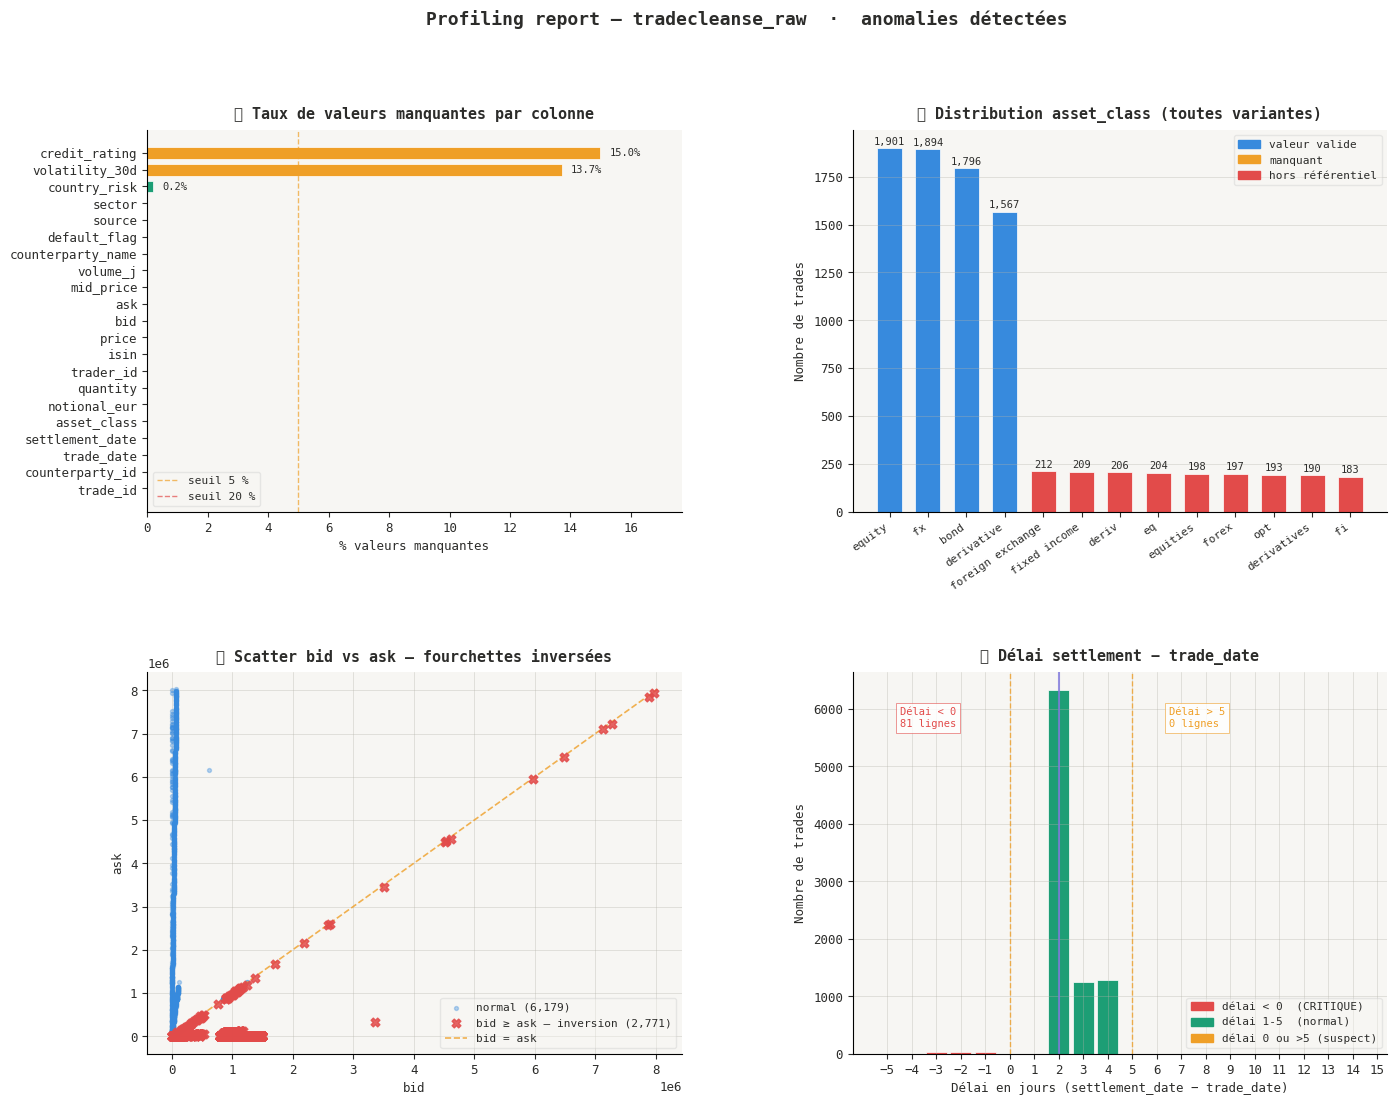

✓ Rapport sauvegardé → outputs/01_profiling_report.png


In [26]:
import matplotlib.pyplot   as plt
import matplotlib.patches  as mpatches
import numpy               as np


# ── Palette cohérente avec le projet ──────────────────────────────────────────
C = {
    "ok"       : "#1D9E75",   # vert  — donnée saine
    "warn"     : "#EF9F27",   # amber — anomalie modérée
    "critical" : "#E24B4A",   # rouge — anomalie critique
    "neutral"  : "#B4B2A9",   # gris  — fond / grille
    "purple"   : "#7F77DD",   # violet — accent
    "blue"     : "#378ADD",   # bleu  — série principale
    "bg"       : "#F7F6F3",   # fond du rapport
    "text"     : "#2C2C2A",   # texte sombre
}

plt.rcParams.update({
    "font.family"       : "monospace",
    "font.size"         : 9,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.color"        : C["neutral"],
    "grid.linewidth"    : 0.4,
    "grid.alpha"        : 0.6,
    "axes.facecolor"    : C["bg"],
    "figure.facecolor"  : "#FFFFFF",
    "text.color"        : C["text"],
    "axes.labelcolor"   : C["text"],
    "xtick.color"       : C["text"],
    "ytick.color"       : C["text"],
})
# setup figure — 2×2 subplots
fig, axes = plt.subplots(
    2, 2,
    figsize     = (16, 12),
    facecolor   = "#FFFFFF",
    gridspec_kw = {"hspace": 0.42, "wspace": 0.32},
)
ax1, ax2, ax3, ax4 = axes.flat

fig.suptitle(
    "Profiling report — tradecleanse_raw  ·  anomalies détectées",
    fontsize=13, fontweight="bold", y=0.98, color=C["text"],
)
# graphique 1 — taux de valeurs manquantes (barh)
# Calcul du taux manquant par colonne, trié croissant pour lecture top→bottom
miss_pct = (
    df_consolidated.isna().mean().mul(100)
    .sort_values(ascending=True)
)

# Couleur selon seuil : rouge > 20 %, amber 5-20 %, vert < 5 %
bar_colors = [
    C["critical"] if v > 20 else (C["warn"] if v > 5 else C["ok"])
    for v in miss_pct
]

bars = ax1.barh(
    miss_pct.index, miss_pct.values,
    color=bar_colors, edgecolor="white", linewidth=0.5, height=0.7,
)

# Étiquette de valeur à droite de chaque barre
for bar, val in zip(bars, miss_pct.values):
    if val > 0.05:
        ax1.text(
            val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=7.5, color=C["text"],
        )

ax1.axvline(5,  color=C["warn"],     lw=1, ls="--", alpha=0.7, label="seuil 5 %")
ax1.axvline(20, color=C["critical"], lw=1, ls="--", alpha=0.7, label="seuil 20 %")
ax1.set_xlabel("% valeurs manquantes")
ax1.set_title("① Taux de valeurs manquantes par colonne", fontweight="bold", pad=8)
ax1.legend(fontsize=8, framealpha=0.4)
ax1.set_xlim(0, miss_pct.max() * 1.18)
ax1.grid(axis="x")
ax1.grid(axis="y", alpha=0)
# graphique 2 — distribution asset_class (toutes variantes)
# Normalisation : strip + lower pour regrouper les variantes de casse/espace
ac_raw = (
    df_consolidated["asset_class"]
    .astype("string")
    .str.strip()
    .str.lower()
    .fillna("__manquant__")
)

VALID_ASSET = {"equity", "bond", "derivative", "fx"}
vc = ac_raw.value_counts()

# Couleur : valeur valide → bleu, manquant → amber, hors-référentiel → rouge
def asset_color(v):
    if v in VALID_ASSET: return C["blue"]
    if v == "__manquant__": return C["warn"]
    return C["critical"]

colors_ac = [asset_color(v) for v in vc.index]
bars2 = ax2.bar(
    range(len(vc)), vc.values,
    color=colors_ac, edgecolor="white", linewidth=0.5, width=0.65,
)
ax2.set_xticks(range(len(vc)))
ax2.set_xticklabels(vc.index, rotation=35, ha="right", fontsize=8)

for bar, val in zip(bars2, vc.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, val + vc.max() * 0.01,
        f"{val:,}", ha="center", fontsize=7.5, color=C["text"],
    )

legend_patches = [
    mpatches.Patch(color=C["blue"],     label="valeur valide"),
    mpatches.Patch(color=C["warn"],     label="manquant"),
    mpatches.Patch(color=C["critical"], label="hors référentiel"),
]
ax2.legend(handles=legend_patches, fontsize=8, framealpha=0.4)
ax2.set_title("② Distribution asset_class (toutes variantes)", fontweight="bold", pad=8)
ax2.set_ylabel("Nombre de trades")
ax2.grid(axis="x", alpha=0)
# graphique 3 — scatter bid vs ask (inversions en évidence)
# Masques : lignes avec bid et ask connus
mask_ba = df_consolidated["bid"].notna() & df_consolidated["ask"].notna()
bid_ = df_consolidated.loc[mask_ba, "bid"]
ask_ = df_consolidated.loc[mask_ba, "ask"]

inversion   = bid_ >= ask_                 # anomalie : bid ≥ ask
normal      = ~inversion

# Échantillonnage pour éviter l'overplotting sur ~8 742 points
MAX_SAMPLE = 3000
idx_norm = bid_[normal].index
idx_inv  = bid_[inversion].index
sample_norm = idx_norm[np.random.choice(len(idx_norm), min(MAX_SAMPLE, len(idx_norm)), replace=False)]

ax3.scatter(
    bid_.loc[sample_norm], ask_.loc[sample_norm],
    s=8, alpha=0.35, color=C["blue"], label=f"normal ({normal.sum():,})", zorder=2,
)
ax3.scatter(
    bid_.loc[idx_inv], ask_.loc[idx_inv],
    s=40, alpha=0.85, color=C["critical"], marker="X",
    label=f"bid ≥ ask — inversion ({inversion.sum():,})", zorder=4,
)

# Droite identité bid = ask (inversions au-dessus)
lims = [
    min(bid_.min(), ask_.min()),
    max(bid_.max(), ask_.max()),
]
ax3.plot(lims, lims, color=C["warn"], lw=1.2, ls="--", alpha=0.8, label="bid = ask", zorder=3)
ax3.set_xlabel("bid")
ax3.set_ylabel("ask")
ax3.set_title("③ Scatter bid vs ask — fourchettes inversées", fontweight="bold", pad=8)
ax3.legend(fontsize=8, framealpha=0.4)
# graphique 4 — délai settlement − trade_date (histogramme)
# Calcul du délai en jours calendaires
for col in ["trade_date", "settlement_date"]:
    if df_consolidated[col].dtype == "object" or str(df_consolidated[col].dtype) == "string":
        df_consolidated[col] = pd.to_datetime(
            df_consolidated[col],
            dayfirst  = True,   # tente JJ/MM/AAAA en priorité
            infer_datetime_format = True,
            errors    = "coerce",
        )
        n_nat = df_consolidated[col].isna().sum()
        print(f"  ✓ {col} re-casté → {df_consolidated[col].dtype}  ({n_nat} NaT)")

mask_dates = df_consolidated["trade_date"].notna() & df_consolidated["settlement_date"].notna()

# Soustraction garantie datetime64 − datetime64 → Timedelta → .dt.days
delay = (
    pd.to_datetime(df_consolidated.loc[mask_dates, "settlement_date"])
    - pd.to_datetime(df_consolidated.loc[mask_dates, "trade_date"])
).dt.days

print(f"✓ Délais calculés sur {mask_dates.sum():,} lignes — min={delay.min()}, max={delay.max()}")

n_neg     = (delay < 0).sum()        # settlement AVANT trade → CRITIQUE
n_zero    = (delay == 0).sum()       # même jour   → suspect
n_late    = (delay > 5).sum()        # > T+5       → à investiguer

# Histogramme complet + zoom sur la zone normale [0, 10]
delay_clipped = delay.clip(-5, 15)   # on clipe pour la lisibilité
bins = np.arange(-5.5, 15.5, 1)

# Couleur par bin : rouge < 0, amber = 0 ou > 5, vert 1-5
bin_centers = (bins[:-1] + bins[1:]) / 2
hist_colors = []
for bc in bin_centers:
    if bc < 0:           hist_colors.append(C["critical"])
    elif bc == 0:        hist_colors.append(C["warn"])
    elif 0 < bc <= 5:    hist_colors.append(C["ok"])
    else:                hist_colors.append(C["warn"])

counts, _ = np.histogram(delay_clipped, bins=bins)
ax4.bar(
    bin_centers, counts,
    width=0.85, color=hist_colors, edgecolor="white", linewidth=0.5,
)

# Repères T+2 (standard actions) et T+0 / limite T+5
ax4.axvline(2,  color=C["purple"], lw=1.5, ls="-",  alpha=0.8, label="T+2 standard")
ax4.axvline(0,  color=C["warn"],   lw=1,   ls="--", alpha=0.8, label="T+0 (suspect)")
ax4.axvline(5,  color=C["warn"],   lw=1,   ls="--", alpha=0.8, label="T+5 (limite)")

# Annotation des anomalies
ax4.text(
    -4.5, counts.max() * 0.9,
    f"Délai < 0\n{n_neg} lignes",
    fontsize=7.5, color=C["critical"], ha="left",
    bbox=dict(fc="white", ec=C["critical"], lw=0.5, pad=3, alpha=0.8),
)
ax4.text(
    6.5, counts.max() * 0.9,
    f"Délai > 5\n{n_late} lignes",
    fontsize=7.5, color=C["warn"], ha="left",
    bbox=dict(fc="white", ec=C["warn"], lw=0.5, pad=3, alpha=0.8),
)

ax4.set_xlabel("Délai en jours (settlement_date − trade_date)")
ax4.set_ylabel("Nombre de trades")
ax4.set_title("④ Délai settlement − trade_date", fontweight="bold", pad=8)
ax4.set_xticks(range(-5, 16))
ax4.legend(fontsize=8, framealpha=0.4)

legend_patches4 = [
    mpatches.Patch(color=C["critical"], label="délai < 0  (CRITIQUE)"),
    mpatches.Patch(color=C["ok"],       label="délai 1-5  (normal)"),
    mpatches.Patch(color=C["warn"],     label="délai 0 ou >5 (suspect)"),
]
ax4.legend(handles=legend_patches4, fontsize=8, framealpha=0.4)
# ── Sauvegarde ────────────────────────────────────────────────────────────────
OUTPUT_PATH = "outputs/01_profiling_report.png"

plt.savefig(
    OUTPUT_PATH,
    dpi         = 180,
    bbox_inches = "tight",
    facecolor   = "white",
)
plt.show()
print(f"✓ Rapport sauvegardé → {OUTPUT_PATH}")